# 🌿 Tunisia Drought Monitor
### VCI · TCI · VHI from MODIS (2001 – 2026)

---

| Cell | What it does |
|------|--------------|
| 1 | Authenticate & initialise Earth Engine |
| 2 | Study parameters (ROI, dates) |
| 3 | Scaling & Conversion Functions |
| 4 | Cloud-masking functions |
| 5 | Monthly weighted-average function |
| 6 | Historical min/max function |
| 7 | VCI · TCI · VHI index functions |
| 8 | Calendar & agricultural year averages |
| 9 | Drought Index Calculation |
| 10 | Map Production |
| 11 | Time-series charts (VCI · TCI · VHI) |
| 12 | Export to NetCDF file |



## 🔐 Cell 1 — Authenticate & Initialise Earth Engine

In [32]:
import ee
# Authenticate once:
ee.Authenticate()

project = ''  # Set your Earth Engine registered Google Cloud project ID
# Initialize
ee.Initialize(project=project, opt_url='https://earthengine-highvolume.googleapis.com')

print('✅ Earth Engine initialised.')

✅ Earth Engine initialised.


## 🗺️ Cell 2 — Study Parameters (ROI & Dates)

In [33]:
# table

table = ee.FeatureCollection('FAO/GAUL/2015/level1')

# Region of interest: northern Tunisian governorates
roi = [
    'Bizerte', 'Ariana', 'Tunis', 'Ben Arous', 'Manouba',
    'Beja', 'Jendouba', 'Le Kef', 'Nabeul', 'Siliana', 'Zaghouan'
]

location = (
    table
    .filter(ee.Filter.eq('ADM0_NAME', 'Tunisia'))
    .filter(ee.Filter.inList('ADM1_NAME', roi))
)
geometry_location = location.geometry()

# Study period
start_time = '2001-01-01'
end_time   = '2026-04-01'

# Satelite data
image_collection  = (ee.ImageCollection('MODIS/061/MOD13A2')
.filterBounds(geometry_location))   # NDVI  (16-day)
image_collection2 = (ee.ImageCollection('MODIS/061/MOD11A2')
.filterBounds(geometry_location))   # LST   (8-day)

print(f'✅ ROI: {len(roi)} governorates | Period: {start_time} → {end_time}')

✅ ROI: 11 governorates | Period: 2001-01-01 → 2026-04-01


## 📈 Cell 3 — Scaling & Conversion Functions

In [34]:
def scale_ndvi_collection(collection):
    def apply_scale(image):
        original_ndvi = image.select('NDVI')
        scaled_ndvi = original_ndvi.multiply(0.0001).rename('NDVI')
        return image.addBands(scaled_ndvi, overwrite=True)
    return collection.map(apply_scale)

def scale_lst_collection_and_convert_to_celsius(collection):
    def apply_scale_and_convert(image):
        original_lst = image.select('LST_Day_1km')
        scaled_lst = original_lst.multiply(0.02).subtract(273.15).rename('LST_Day_1km') # K to C
        return image.addBands(scaled_lst, overwrite=True)
    return collection.map(apply_scale_and_convert)

def extract_mean_for_roi(image_collection, geometry, band_name):
    """
    Extracts the mean value of a specified band for the given geometry
    from each image in an ImageCollection.
    """
    def get_mean(image):
        # Reduce the image by the region, taking the mean
        mean_value = image.select(band_name).reduceRegion(
            reducer=ee.Reducer.mean(),
            geometry=geometry,
            scale=1000, # Use a suitable scale for your data resolution
            maxPixels=1e9
        ).get(band_name)

        # Get the date from the image metadata
        date = image.date().format('YYYY-MM-dd')

        return ee.Feature(None, {'date': date, 'mean_value': mean_value})

    # Map the function over the image collection and convert to a FeatureCollection
    feature_collection = image_collection.map(get_mean)

    # Convert the FeatureCollection to a list of dictionaries for easier DataFrame conversion
    list_of_features_info = feature_collection.getInfo()
    data = [{'date': f['properties']['date'], 'mean_value': f['properties']['mean_value']} for f in list_of_features_info['features']]

    return data

print('✅ Scaling and conversion functions defined.')

✅ Scaling and conversion functions defined.


## ☁️ Cell 4 — Cloud Masking Functions

In [35]:
def mask_clouds_mod13(image):
    """
    MOD13A2 (NDVI) quality mask.
    SummaryQA: 0 = Good data, 1 = Marginal  →  keep both, discard 2 (snow) & 3 (cloud).
    """
    qa   = image.select('SummaryQA')
    mask = qa.lte(1)
    return image.updateMask(mask)


def mask_clouds_mod11(image):
    """
    MOD11A2 (LST) quality mask.
    QC_Day bits 0-1: 0b00 = good LST, 0b01 = produced (other quality).
    We keep pixels where the first 2 bits ≤ 1.
    """
    qc   = image.select('QC_Day')
    mask = qc.bitwiseAnd(3).lte(1)
    return image.updateMask(mask)


print('✅ Cloud masking functions defined.')

✅ Cloud masking functions defined.


## 📅 Cell 5 — Monthly Weighted-Average Function

In [36]:
def to_monthly_weighted(collection, band_name, start_date, end_date, composite_days):
    """
    Convert a composite image collection (e.g. 16-day NDVI) to monthly images
    by weighting each composite by the number of days it overlaps the month.
    """
    ms_per_day = 86_400_000

    n_months = (
        end_date.get('year').subtract(start_date.get('year'))
        .multiply(12)
        .add(end_date.get('month').subtract(start_date.get('month')))
    )

    counter     = ee.List.sequence(0, n_months)
    month_dates = counter.map(lambda n: start_date.advance(n, 'month').millis())

    def make_monthly(month_start_millis):
        month_start   = ee.Date(month_start_millis)
        month_end     = month_start.advance(1, 'month')
        days_in_month = month_end.difference(month_start, 'day')
        year          = month_start.get('year')
        month         = month_start.get('month')

        candidates = (
            collection
            .filterDate(
                month_start.advance(ee.Number(composite_days).multiply(-1).add(1), 'day'),
                month_end
            )
            .select(band_name)
        )

        def weight_image(img):
            win_start     = img.date()
            win_end       = win_start.advance(composite_days, 'day')
            clamped_start = win_start.millis().max(month_start.millis())
            clamped_end   = win_end.millis().min(month_end.millis())

            days_inside = (
                ee.Number(clamped_end)
                .subtract(clamped_start)
                .divide(ms_per_day)
                .max(0)
            )
            weight_img = ee.Image(img).multiply(0).add(days_inside).toFloat()
            return (
                img.multiply(days_inside)
                .rename('weighted_value')
                .toFloat()
                .addBands(weight_img.rename('weight'))
            )

        weighted     = candidates.map(weight_image)
        weighted_sum = weighted.select('weighted_value').sum()
        weight_sum   = weighted.select('weight').sum()

        return (
            weighted_sum
            .divide(weight_sum)
            .toFloat()
            .rename(band_name + '_monthly')
            .set({
                'system:time_start': month_start.millis(),
                'year':              year,
                'month':             month,
                'date':              month_start.format('YYYY-MM'),
                'days_in_month':     days_in_month
            })
        )

    return ee.ImageCollection(month_dates.map(make_monthly))


print('✅ Monthly weighted-average function defined.')

✅ Monthly weighted-average function defined.


## 📊 Cell 6 — Historical Min & Max Function

In [37]:
def add_historical_min_max(monthly_collection, band_name):
    """
    For every image in the collection, attach two extra bands:
      <band_name>_min  —  historical minimum for that calendar month
      <band_name>_max  —  historical maximum for that calendar month
    These baselines are used to compute VCI and TCI.
    """
    def add_baselines(img):
        m = img.get('month')

        historical = (
            monthly_collection
            .filter(ee.Filter.calendarRange(m, m, 'month'))
            .select(band_name)
        )

        min_img = historical.min().rename(band_name + '_min')
        max_img = historical.max().rename(band_name + '_max')

        return img.addBands([min_img, max_img])

    return monthly_collection.map(add_baselines)


print('✅ Historical min/max function defined.')

✅ Historical min/max function defined.


## 🌡️ Cell 7 — VCI, TCI & VHI Index Functions

In [38]:
# VCI  Vegetation Condition Index
def calculate_vci(collection_with_baselines, band_name):
    """VCI = ((Value − Min) / (Max − Min)) × 100"""
    def compute(img):
        val = img.select(band_name)
        mn  = img.select(band_name + '_min')
        mx  = img.select(band_name + '_max')
        vci = (
            val.subtract(mn)
            .divide(mx.subtract(mn).max(0.0001))
            .multiply(100)
            .rename('VCI')
        )
        return img.addBands(vci)
    return collection_with_baselines.map(compute)


#  TCI : Temperature Condition Index
def calculate_tci(collection_with_baselines, band_name):
    """TCI = ((Max − Value) / (Max − Min)) × 100"""
    def compute(img):
        val = img.select(band_name)
        mn  = img.select(band_name + '_min')
        mx  = img.select(band_name + '_max')
        rng = mx.subtract(mn).max(0.0001)
        tci = mx.subtract(val).divide(rng).multiply(100).rename('TCI')
        return img.addBands(tci)
    return collection_with_baselines.map(compute)


# VHI : Vegetation Health Index
def calculate_vhi(vci_collection, tci_collection, alpha_weight=0.5):
    """VHI = alpha × VCI + (1 − alpha) × TCI"""
    a = alpha_weight
    b = 1 - a

    def compute(vci_img):
        time    = vci_img.get('system:time_start')
        tci_img = ee.Image(
            tci_collection
            .filter(ee.Filter.eq('system:time_start', time))
            .first()
        )
        vci      = vci_img.select('VCI')
        tci      = tci_img.select('TCI')
        lst_base = tci_img.select('LST_Day_1km_monthly')
        vhi      = vci.multiply(a).add(tci.multiply(b)).rename('VHI')
        combined = vci_img.addBands([lst_base, tci, vhi])
        return combined.select(['NDVI_monthly', 'LST_Day_1km_monthly', 'VCI', 'TCI', 'VHI'])

    return vci_collection.map(compute)


print('✅ VCI, TCI and VHI functions defined.')

✅ VCI, TCI and VHI functions defined.


## 📆 Cell 8 — hydrological Year Aggregation Functions

In [39]:
def to_hydrological_year(monthly_collection, start_year, end_year):
    """Average monthly images into agricultural seasons (Sep Y → Aug Y+1)."""
    ag_years = ee.List.sequence(start_year, ee.Number(end_year).subtract(1))

    def make_ag_year(y):
        y_num        = ee.Number(y)
        start_date   = ee.Date.fromYMD(y_num,        9, 1)
        end_date     = ee.Date.fromYMD(y_num.add(1), 9, 1)
        season_label = ee.String(y_num.int()).cat('-').cat(ee.String(y_num.add(1).int()))

        return monthly_collection.filterDate(start_date, end_date).mean().set({
            'start_year':        y,
            'start_year_str':    y_num.format(), # Add a string representation of the year
            'system:time_start': start_date.millis(),
            'date_label':        season_label
        })

    return ee.ImageCollection(ag_years.map(make_ag_year))


print('✅ hydrological-year functions defined.')

✅ hydrological-year functions defined.


## ⚙️ Cell 9 — Drought Index Calculation

In [40]:
print('Running pipeline …')

start_date = ee.Date(start_time)
end_date   = ee.Date(end_time)

# Step 1 — Apply scaling factors and convert LST to Celsius
initial_scaled_ndvi_collection = scale_ndvi_collection(image_collection)
initial_scaled_lst_collection = scale_lst_collection_and_convert_to_celsius(image_collection2)

# Step 2 — Apply cloud masks (to the already scaled collections)
masked_ndvi = initial_scaled_ndvi_collection.map(mask_clouds_mod13)
masked_lst  = initial_scaled_lst_collection.map(mask_clouds_mod11)

# Step 3 — Convert to monthly composites
monthly_ndvi = to_monthly_weighted(masked_ndvi, 'NDVI',        start_date, end_date, 16)
monthly_lst  = to_monthly_weighted(masked_lst,  'LST_Day_1km', start_date, end_date,  8)

# Step 4 — Attach historical min/max baselines
ndvi_with_baselines = add_historical_min_max(monthly_ndvi, 'NDVI_monthly')
lst_with_baselines  = add_historical_min_max(monthly_lst,  'LST_Day_1km_monthly')

# Step 5 — Calculate drought indices
final_vci = calculate_vci(ndvi_with_baselines, 'NDVI_monthly')
final_tci = calculate_tci(lst_with_baselines,  'LST_Day_1km_monthly')
final_vhi = calculate_vhi(final_vci, final_tci, alpha_weight=0.5)

# Step 6 — Temporal aggregations
s_year = int(start_time[:4])
e_year = int(end_time[:4])

hydrological_year_indices = to_hydrological_year(final_vhi, s_year, e_year-1)

print('✅ Pipeline built successfully.')

Running pipeline …
✅ Pipeline built successfully.
   final_vhi                : monthly VCI / TCI / VHI
   calendar_year_indices    : yearly averages (Jan–Dec)
   agricultural_year_indices: seasonal averages (Sep–Aug)
   agricultural_year_ndvi   : seasonal NDVI averages (Sep–Aug)
   agricultural_year_lst    : seasonal LST averages (Sep–Aug)


## ⚙️ Cell 10 — Map Production

In [41]:
!pip install --upgrade --pre xee
!pip install -U geemap
!pip install rioxarray

In [42]:
import xarray as xr
from xee import helpers
import geemap
import shapely.geometry  # Import shapely

# Convert ee.Geometry to GeoJSON, then to shapely geometry
geojson_data = geometry_location.getInfo()
shapely_geometry = shapely.geometry.shape(geojson_data)

grid_params = helpers.fit_geometry(
    geometry=shapely_geometry,
    geometry_crs='EPSG:4326',   # CRS of the input geometry
    grid_crs='EPSG:4326',       # Keep plotting CRS as geographic degrees
    grid_scale=(0.01, -0.01)    # Keep plotting resolution in degrees
)

# Load & clip datasets — NDVI/LST (continuous) and VCI/TCI/VHI (classified)
ds = xr.open_dataset(hydrological_year_indices, engine='ee', **grid_params)
shp = geemap.ee_to_gdf(location)
ds_clip = ds.rio.clip([shapely_geometry],'EPSG:4326')

print('✅ NDVI, LST, and VCI/TCI/VHI datasets loaded and clipped.')


✅ NDVI, LST, and VCI/TCI/VHI datasets loaded and clipped.


In [43]:
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# ── Shared axis formatters (used by both map types) ───────────────────────
def format_lon(x, pos):
    return f"{abs(x):.1f}°"

def format_lat(y, pos):
    return f"{abs(y):.1f}°"

def _style_axes(g, data_array):
    for ax, t in zip(g.axs.flat, data_array['time'].values):
        year = str(t)[:4]
        next_year = int(year) + 1
        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.set_title(f"{year}/{next_year}")
        ax.xaxis.set_major_formatter(FuncFormatter(format_lon))
        ax.yaxis.set_major_formatter(FuncFormatter(format_lat))

# ── Continuous maps (NDVI, LST) ────────────────────────────────────────────
def plot_continuous_maps(data_array, var_name, cmap='viridis', figsize=(15, 15),
                          col_wrap=4, cbar_label=None, main_title=None):
    # No `levels` argument -> xarray/matplotlib uses a continuous, unclassed
    # gradient scaled to the actual min/max of the data (vmin/vmax), instead
    # of snapping values into discrete bins like the VCI/TCI/VHI maps.
    g = data_array.plot(
        x='x',
        y='y',
        col='time',
        cmap=cmap,
        col_wrap=col_wrap,
        figsize=figsize,
        robust=True,  # scales color range to the 2nd-98th percentile, ignoring outliers
        cbar_kwargs={'label': cbar_label or var_name},
    )
    _style_axes(g, data_array)
    g.fig.suptitle(
        main_title or f'Agricultural Year {var_name} Maps (Continuous)',
        fontsize=20,
        y=1.02
    )
    plt.show()

# ── Classified drought-severity maps (VCI, TCI, VHI) ───────────────────────
my_levels = [0, 10, 20, 30, 40, 100]
colors = ['#8b0000', '#ff0000', '#ffa500', '#ffff00', '#008000']
custom_cmap = mcolors.ListedColormap(colors)

def plot_index_maps(data_array, index_name, custom_cmap, my_levels, figsize=(15, 15), col_wrap=4):
    labels = ['Extreme (0–10)', 'Severe (10–20)',
              'Moderate (20–30)', 'Mild (30–40)',
              'No Drought (40–100)']

    g = data_array.plot(
        x='x',
        y='y',
        col='time',
        cmap=custom_cmap,
        col_wrap=col_wrap,
        levels=my_levels,
        figsize=figsize
    )
    _style_axes(g, data_array)

    legend_patches = [
        mpatches.Patch(facecolor=colors[i], label=label)
        for i, label in enumerate(labels)
    ]
    g.fig.legend(
        handles=legend_patches,
        loc='lower center',
        ncol=len(labels),
        fontsize=9,
        frameon=True,
        bbox_to_anchor=(0.47, 0.0),
        bbox_transform=g.fig.transFigure
    )
    g.fig.suptitle(
        f'Hydrological Year {index_name} Maps – North Tunisia (2001/2002 – 2024/2025)',
        fontsize=20,
        y=1.02
    )
    plt.show()


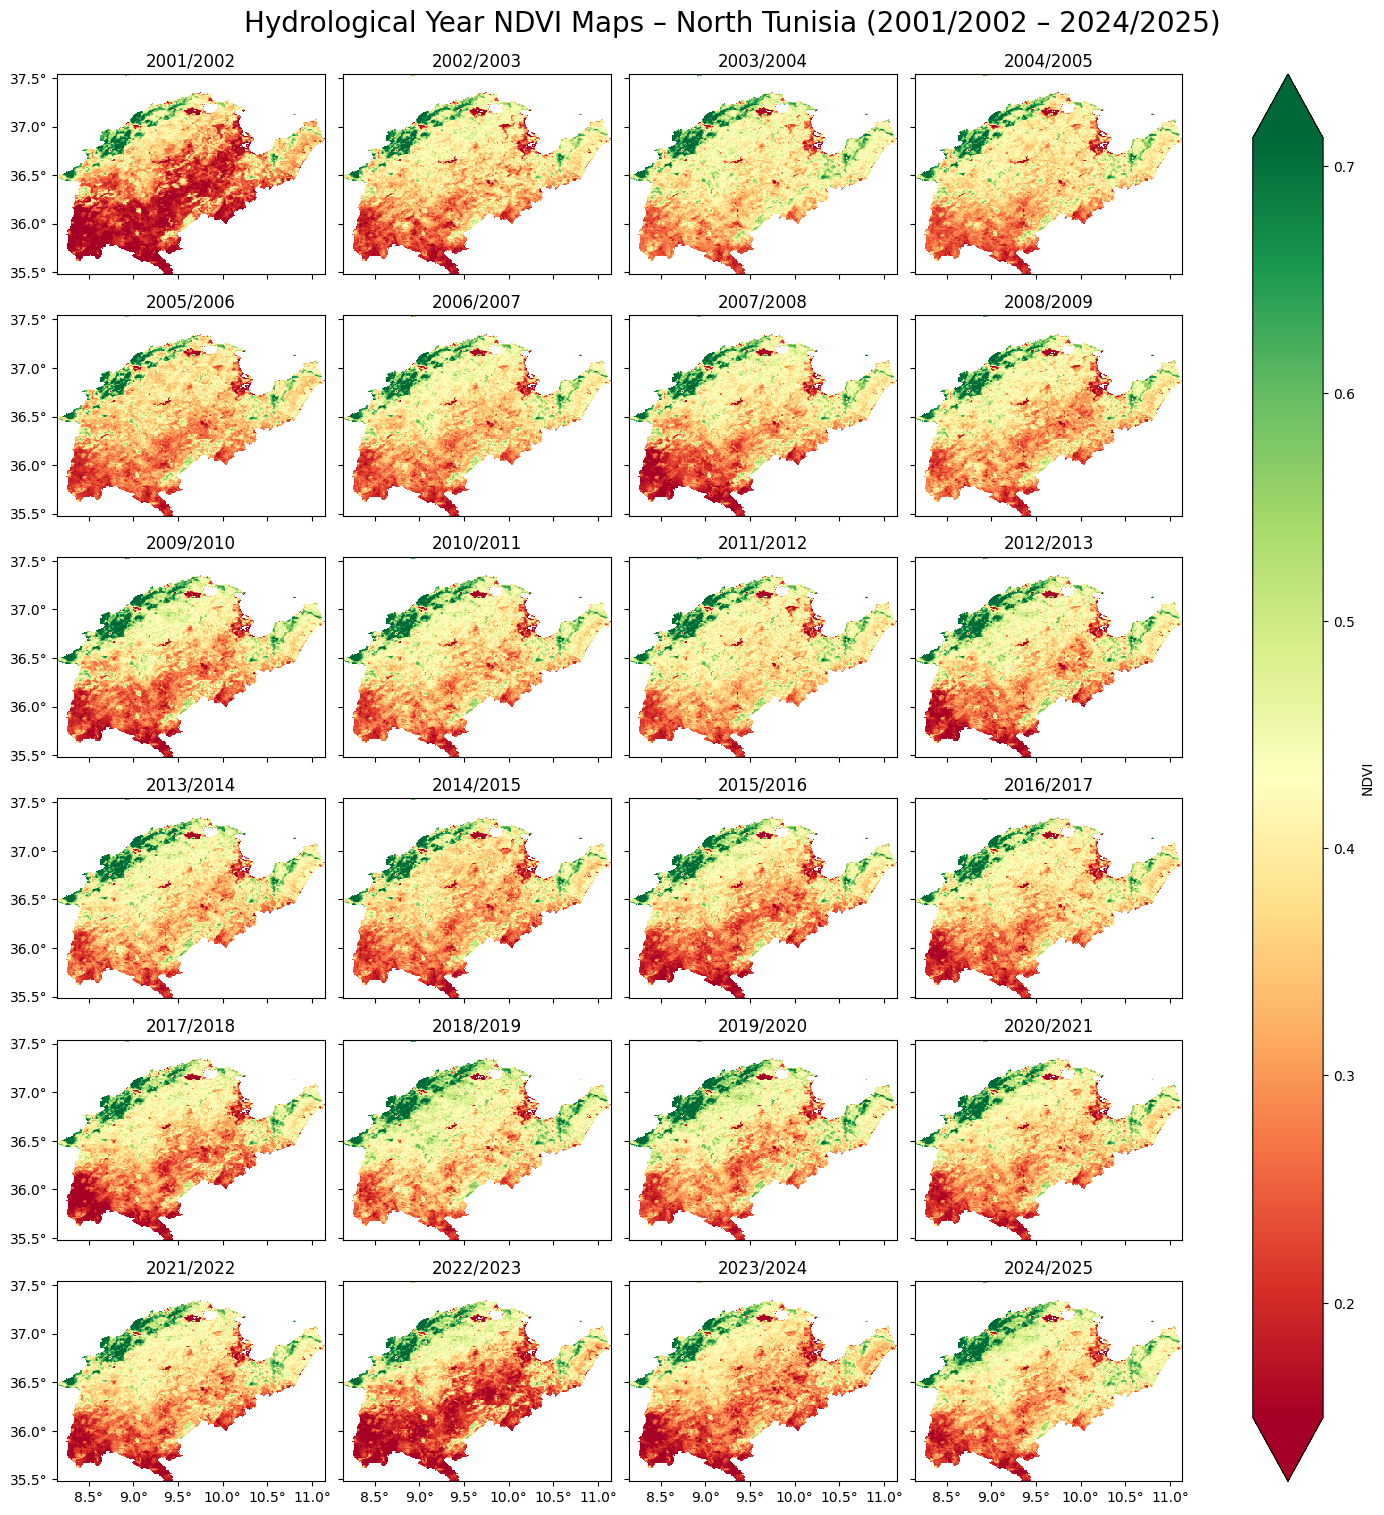

In [44]:
# NDVI MAP — continuous green gradient (low -> high vegetation greenness)
plot_continuous_maps(ds_clip.NDVI_monthly, 'NDVI', cmap='RdYlGn',
                      cbar_label='NDVI',
                      main_title='Hydrological Year NDVI Maps – North Tunisia (2001/2002 – 2024/2025)')


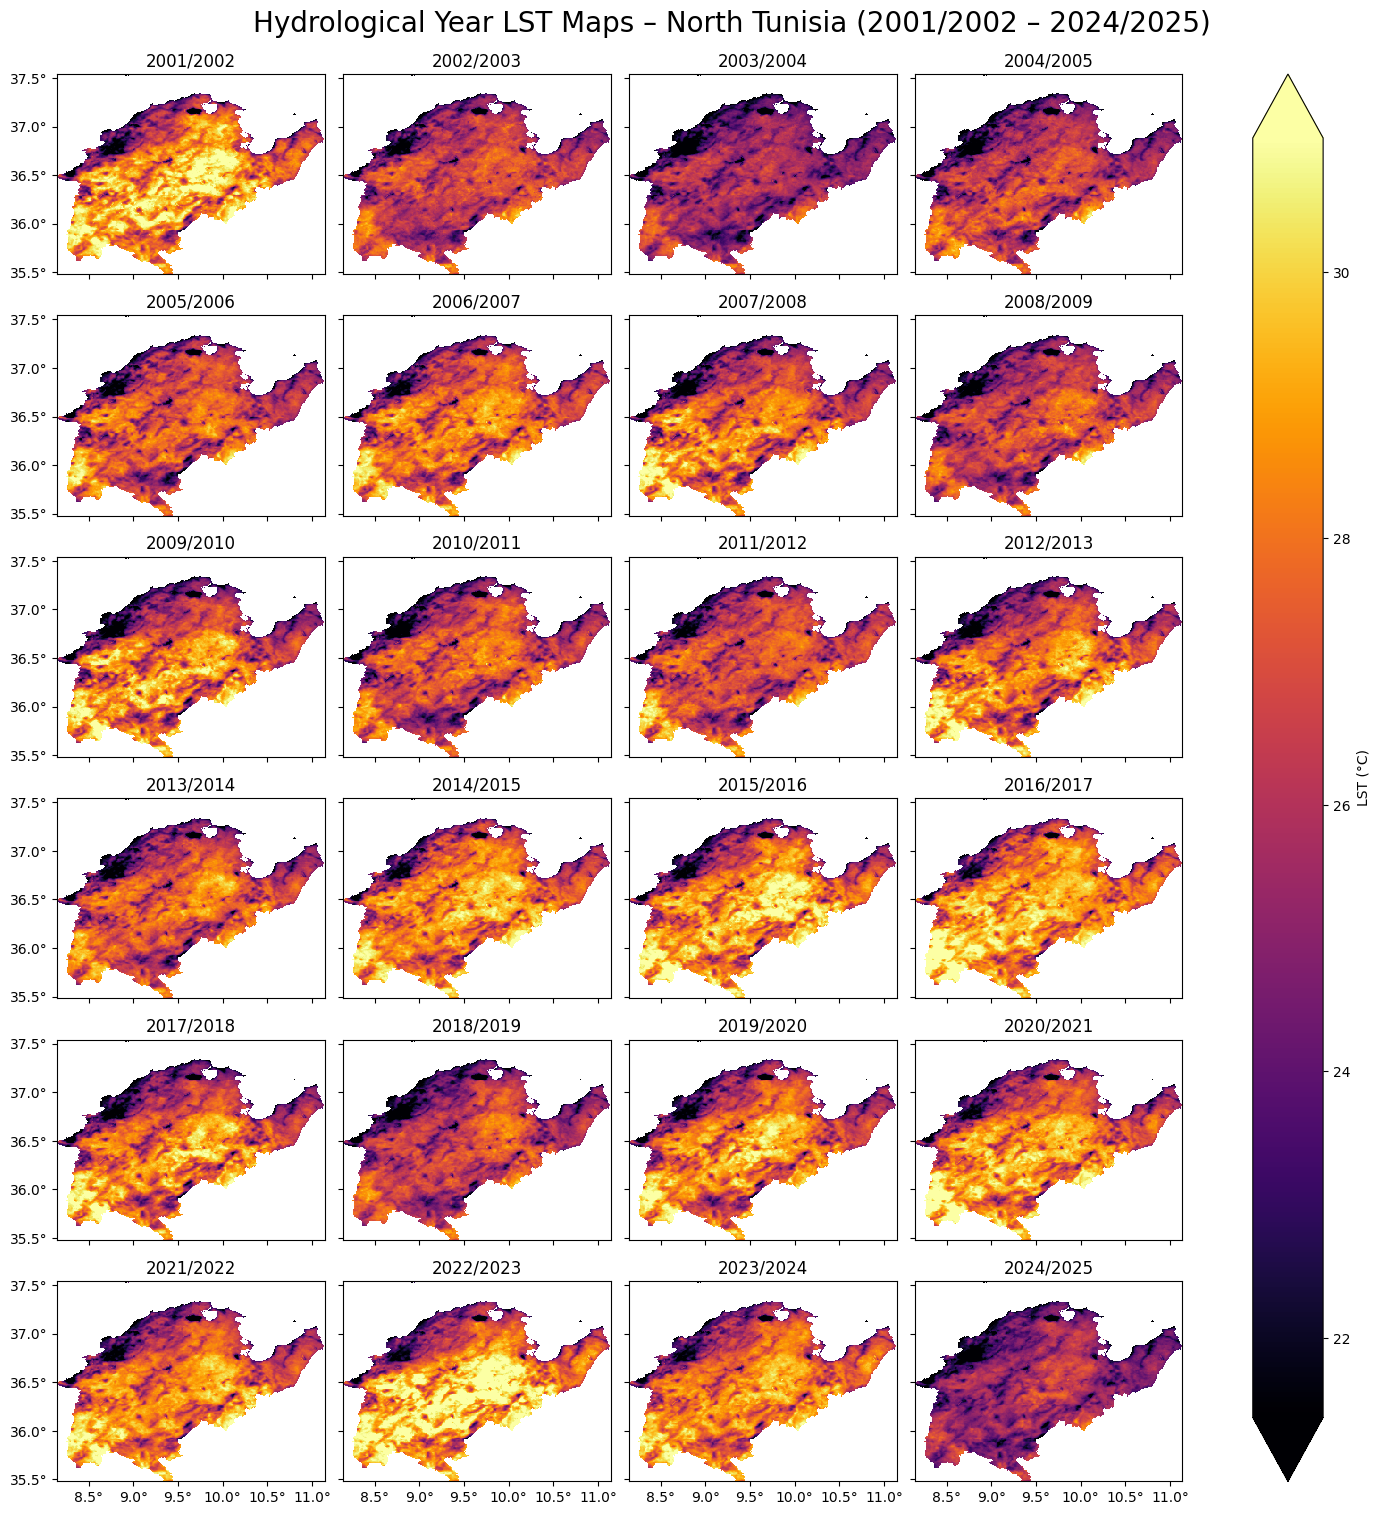

In [45]:
# LST MAP — continuous thermal gradient (cool -> hot land surface temperature)
plot_continuous_maps(ds_clip.LST_Day_1km_monthly, 'LST', cmap='inferno',
                      cbar_label='LST (°C)',
                      main_title='Hydrological Year LST Maps – North Tunisia (2001/2002 – 2024/2025)')


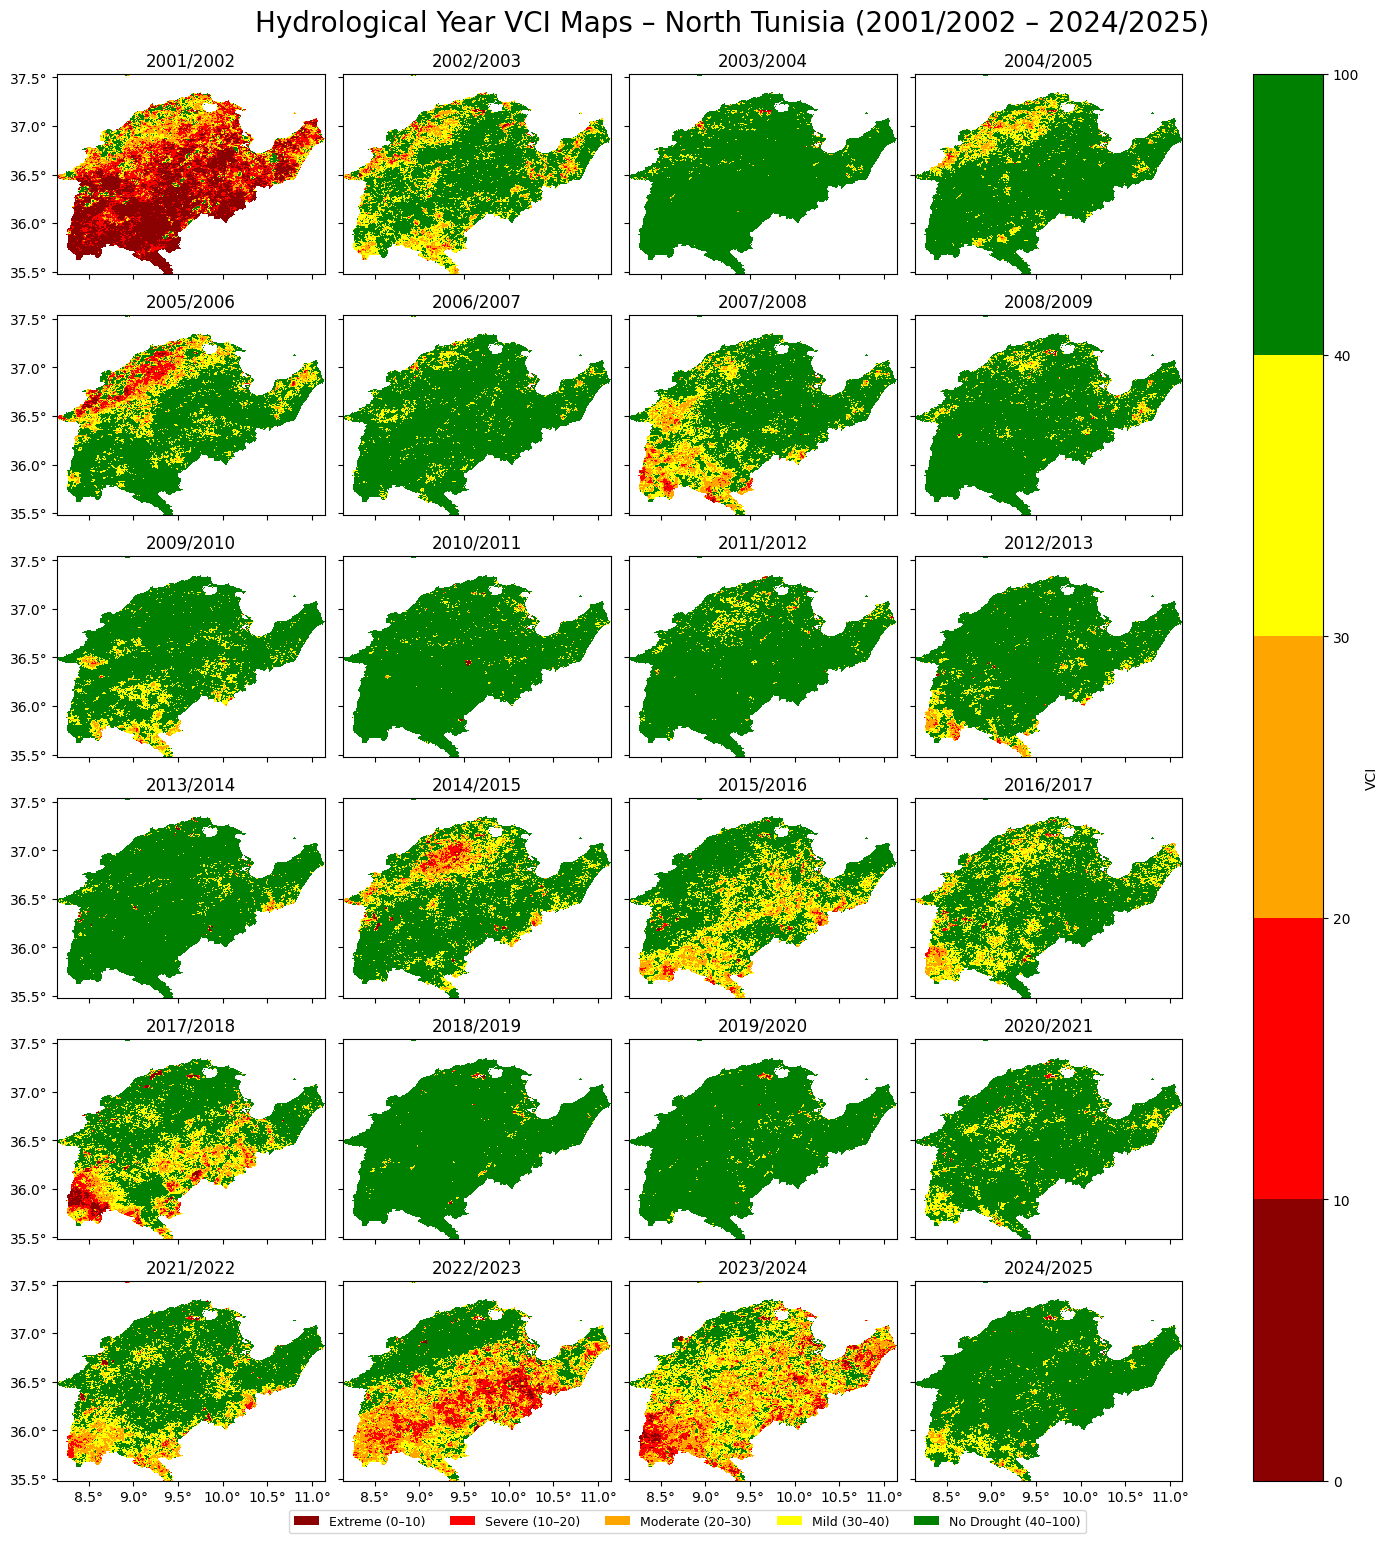

In [46]:
# VCI MAP
plot_index_maps(ds_clip.VCI, 'VCI', custom_cmap, my_levels)


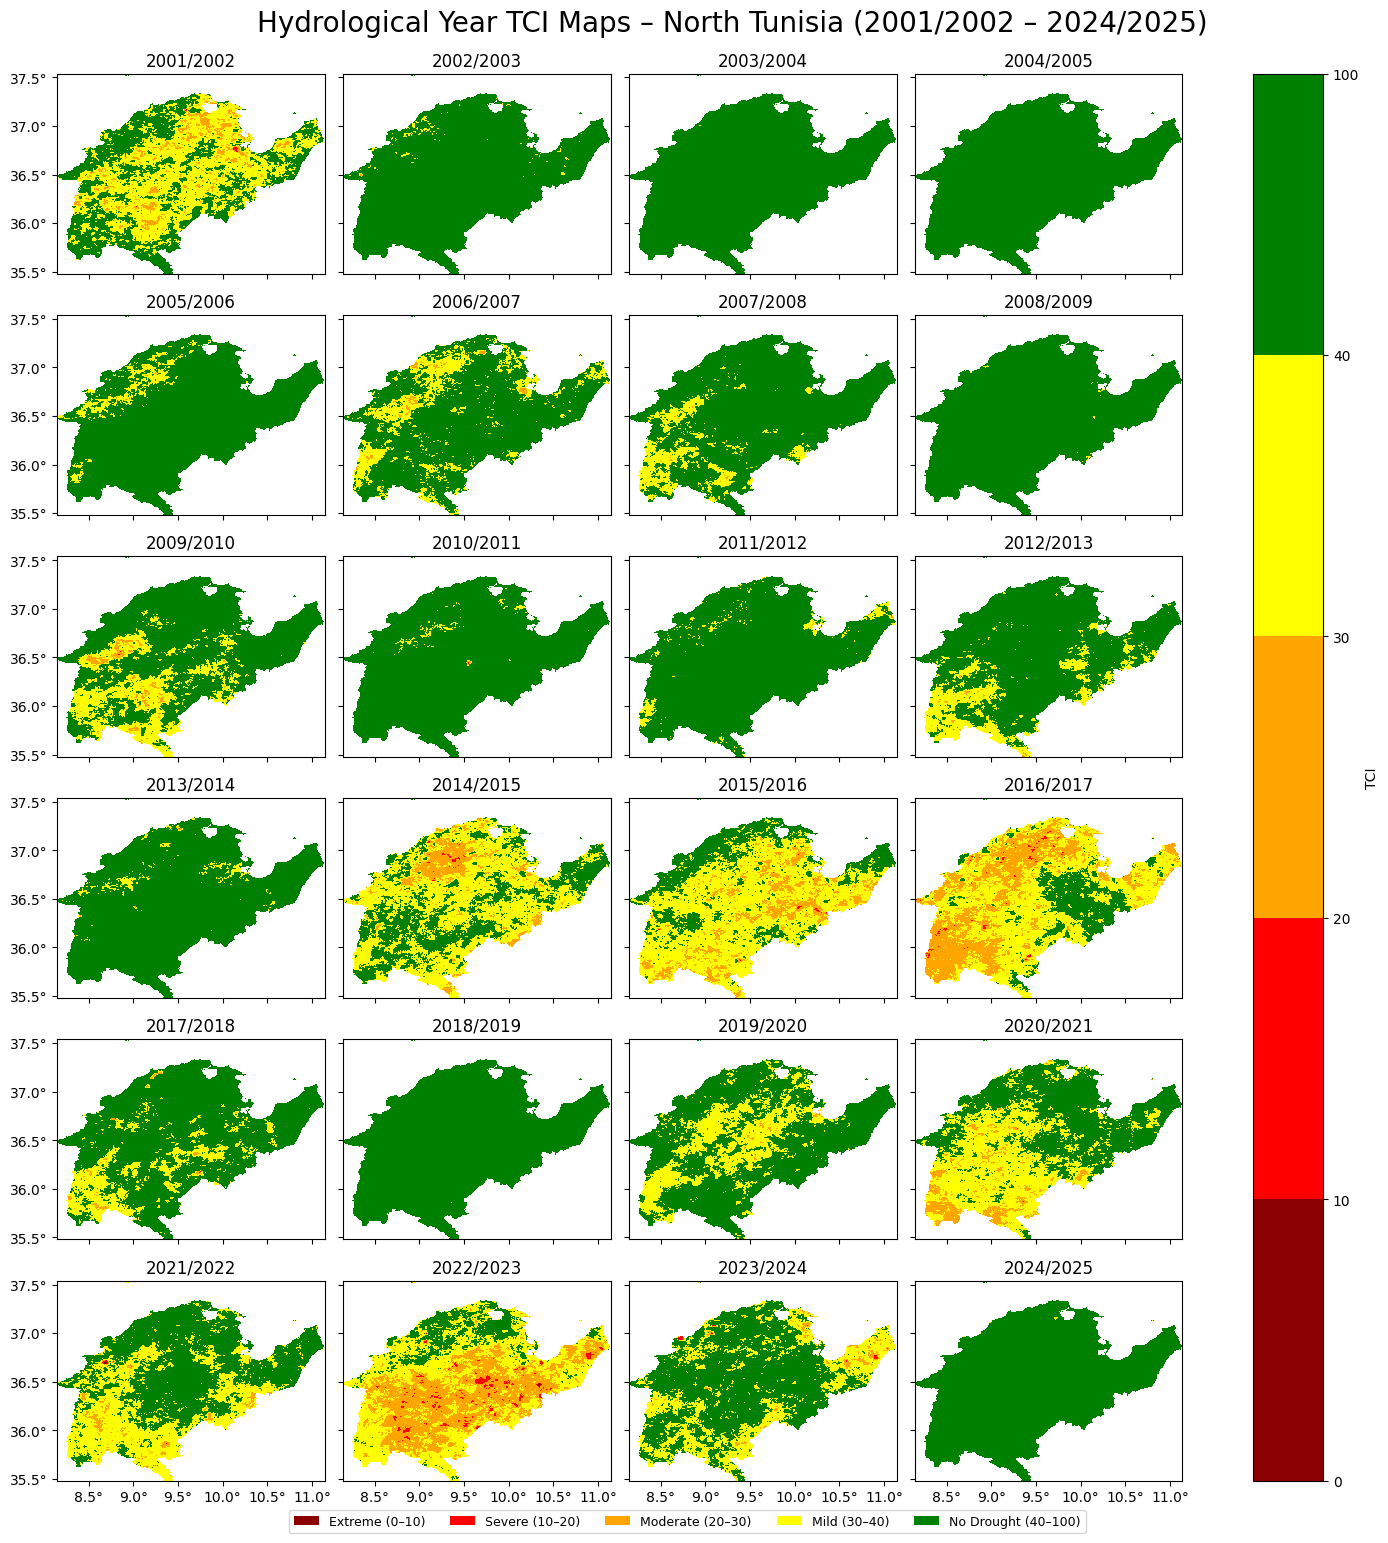

In [47]:
# TCI MAP
plot_index_maps(ds_clip.TCI, 'TCI', custom_cmap, my_levels)


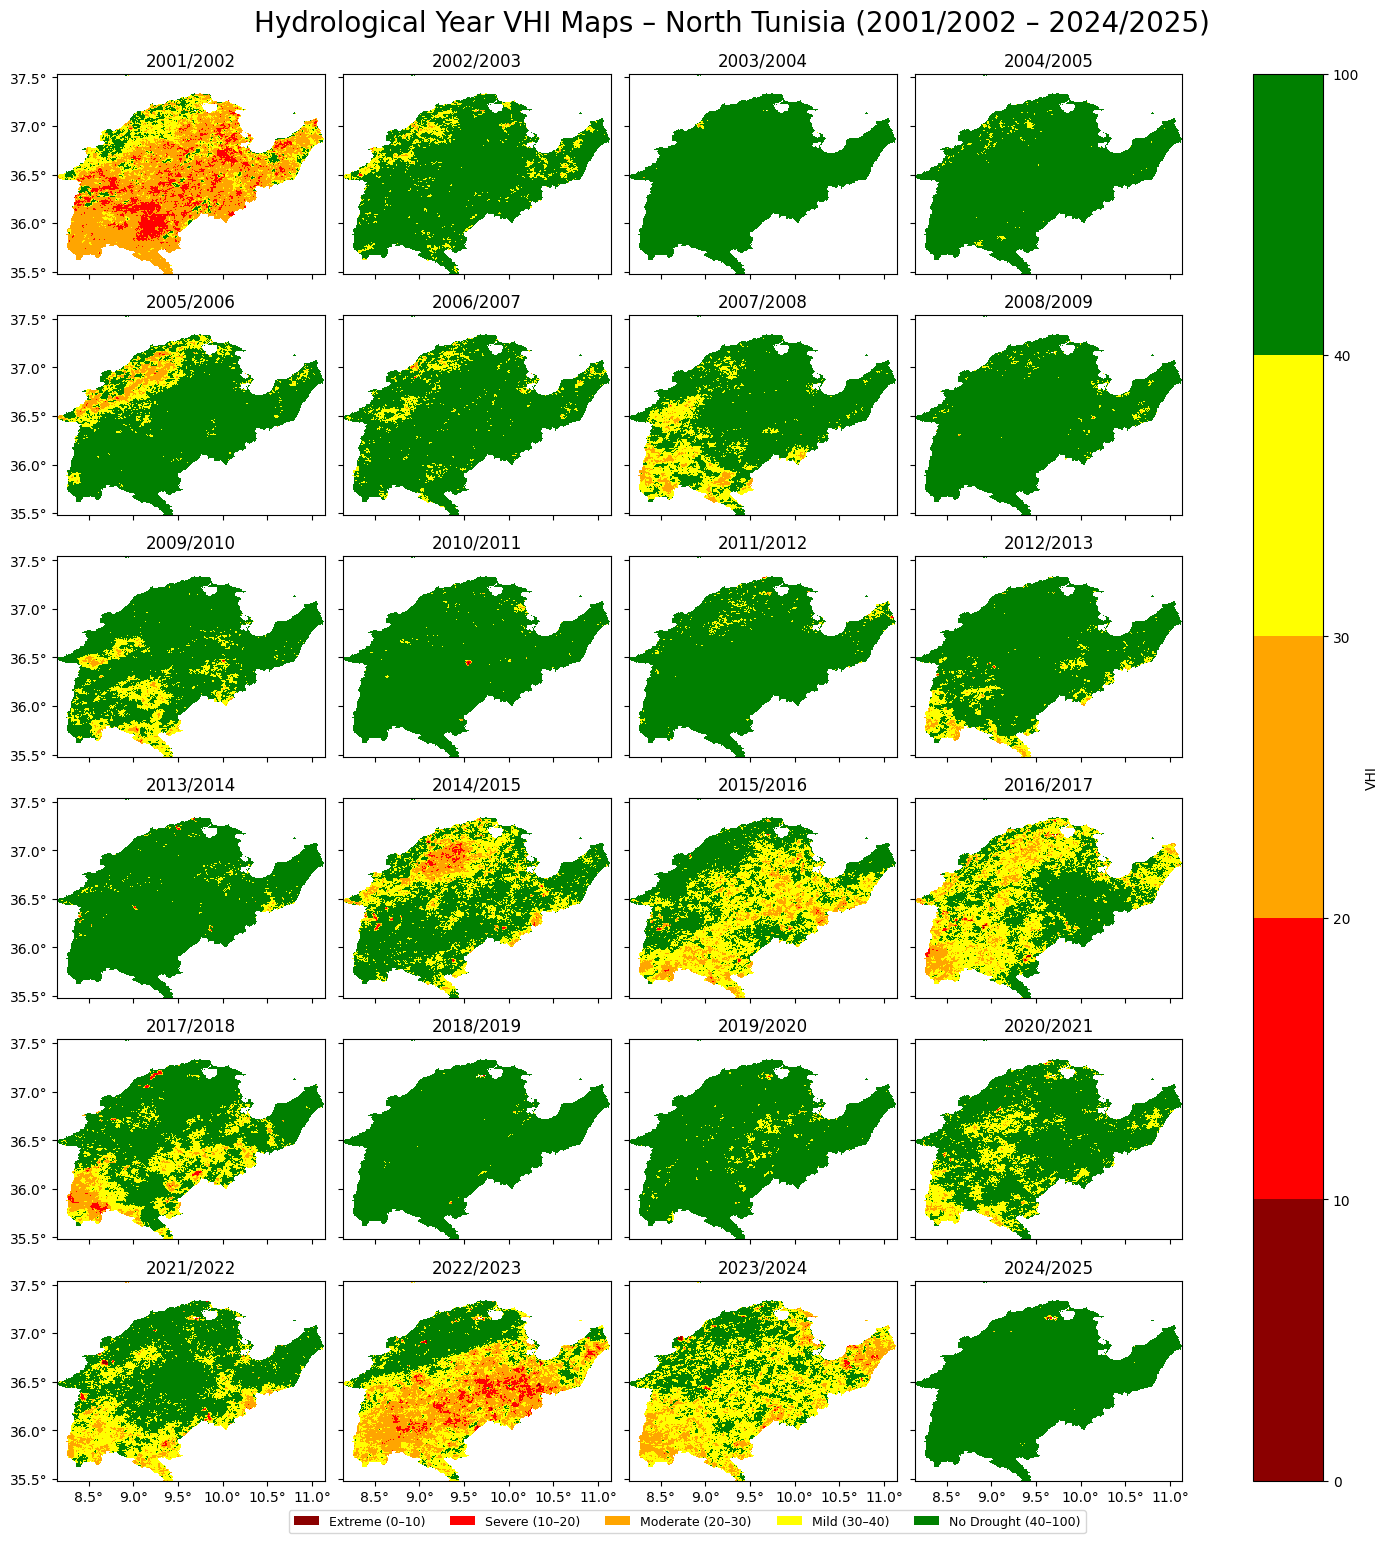

In [48]:
# VHI MAP
plot_index_maps(ds_clip.VHI, 'VHI', custom_cmap, my_levels)


## 📈 Cell 11 — Time-Series Charts (NDVI, LST, VCI, TCI, VHI)

In [49]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


def plot_index(dataset, band_name, color="#d62728"):
    # 1. Calculate the spatial average over latitude/longitude for each date
    spatial_dims = ("y", "x")  # adjust if named 'lat', 'lon', or 'y', 'x'
    mean_data = dataset[band_name].mean(dim=spatial_dims)

    # 2. Convert to a simple pandas DataFrame for plotting
    df = mean_data.to_dataframe(name="mean_value").reset_index()

    # 3. Create the plot
    plt.figure(figsize=(12, 4))
    sns.lineplot(
        data=df,
        x="time",
        y="mean_value",
        color=color,
        linewidth=2,
        marker="o",
        label=band_name,
    )

    # 4. Styling
    plt.title(
        f"{band_name} Time Series – North Tunisia",
        fontsize=13,
        fontweight="bold",
    )
    plt.xlabel("Date", fontsize=11)
    plt.ylabel(f"Mean {band_name} Value", fontsize=11)
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()
    return df

def plot_band(band, color):
    # Using ds_clip as it's the processed and clipped dataset from Cell 10.
    plot_index(ds_clip, band_name=band, color=color)

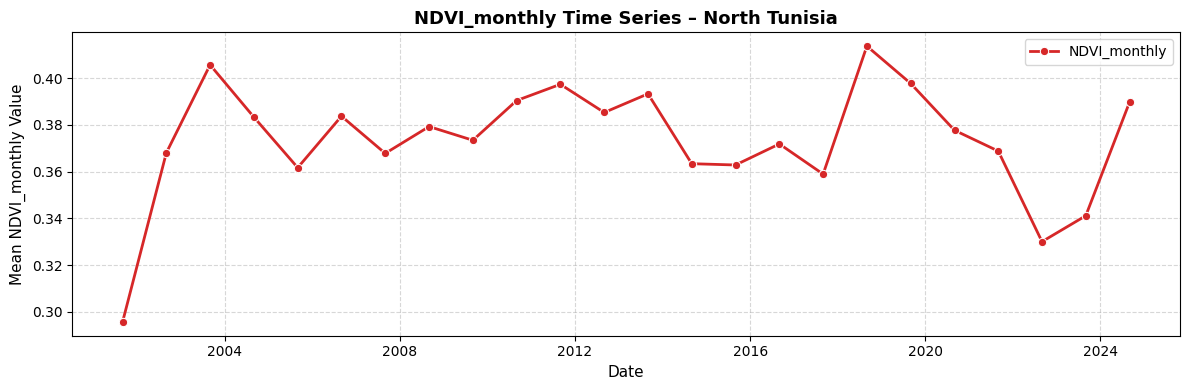

In [50]:
# NDVI
plot_band("NDVI_monthly", "#d62728")


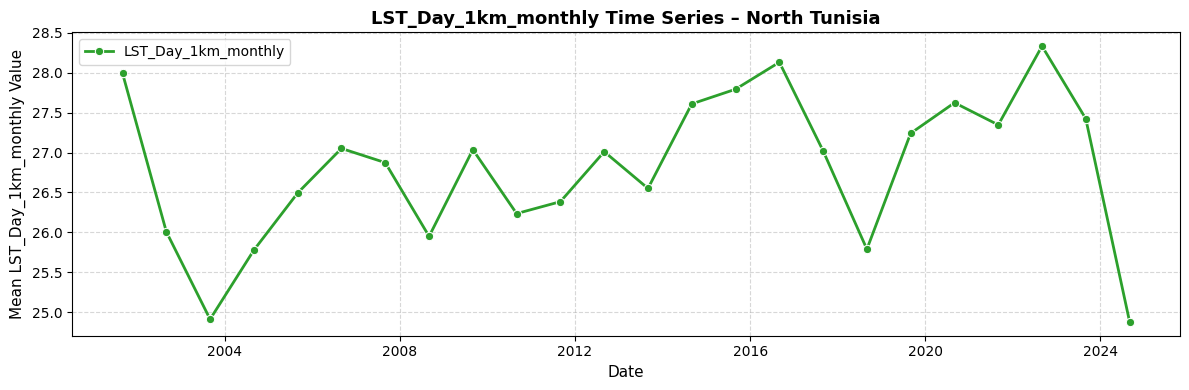

In [51]:
# LST
plot_band("LST_Day_1km_monthly", "#2ca02c")


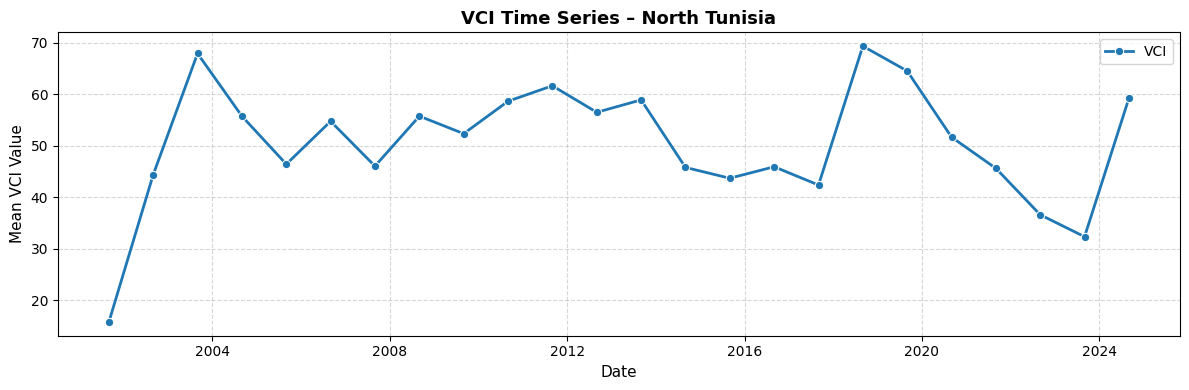

In [52]:
# VCI
plot_band("VCI", "#1f77b4")

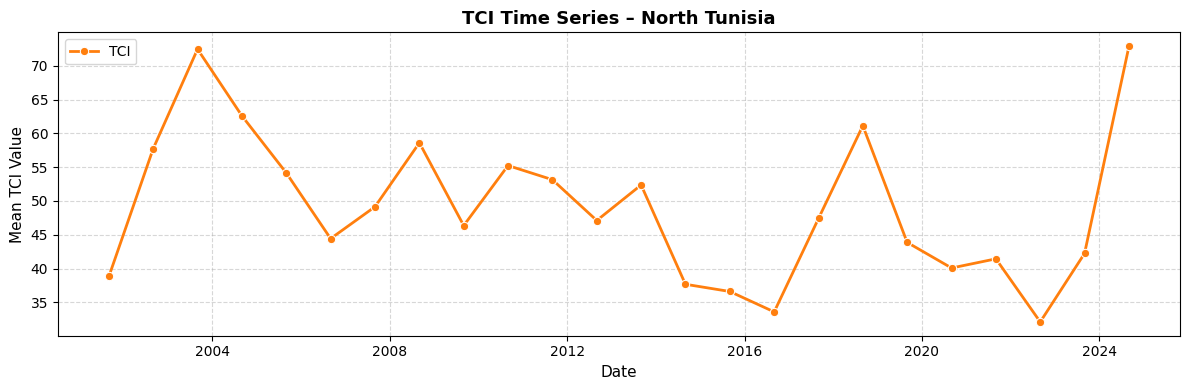

In [53]:
# TCI
plot_band("TCI", "#ff7f0e")

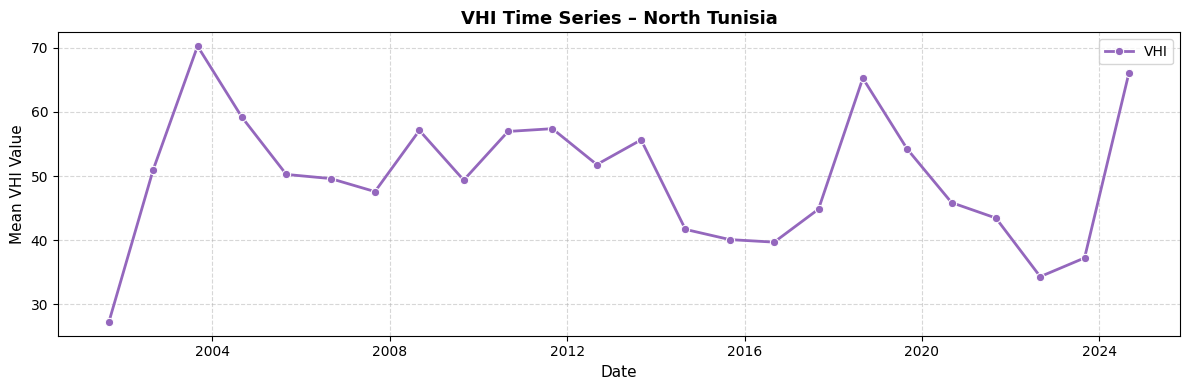

In [54]:
# VHI
plot_band("VHI", "#9467bd")

# 📩 Export file

In [55]:
import xarray as xr
from xee import helpers
import shapely.geometry
import rioxarray
import os
import zipfile

# ============================================================
# SETTINGS
# ============================================================
output_dir = '/content/data/processed/'
monthly_dir = os.path.join(output_dir, 'monthly')
yearly_dir = os.path.join(output_dir, 'yearly')
os.makedirs(monthly_dir, exist_ok=True)
os.makedirs(yearly_dir, exist_ok=True)

geojson_data = geometry_location.getInfo()
shapely_geometry = shapely.geometry.shape(geojson_data)

grid_params = helpers.fit_geometry(
    geometry=shapely_geometry,
    geometry_crs='EPSG:4326',
    grid_crs='EPSG:4326',
    grid_scale=(0.01, -0.01)
)

# ============================================================
# FUNCTION TO SAVE EACH INDEX
# ============================================================
def save_index(collection, band, output_folder, filename):
    ds = xr.open_dataset(collection.select(band), engine='ee', **grid_params)
    ds = ds.rio.clip([shapely_geometry], crs='EPSG:4326', drop=True)
    path = os.path.join(output_folder, filename)
    ds.to_netcdf(path)
    print(f"✅ {path}")
    return path

# ============================================================
# MONTHLY
# ============================================================
monthly_files = []
for band in ['NDVI_monthly', 'LST_Day_1km_monthly', 'VCI', 'TCI', 'VHI']:
    monthly_files.append(
        save_index(final_vhi, band, monthly_dir, f'{band}_monthly.nc')
    )

# ============================================================
# HYDROLOGICAL YEAR
# ============================================================
hydro_files = []
for band in ['NDVI_monthly', 'LST_Day_1km_monthly', 'VCI', 'TCI', 'VHI']:
    hydro_files.append(
        save_index(
            hydrological_year_indices,
            band,
            yearly_dir,
            f'{band}_hydrological_year.nc'
        )
    )

# ============================================================
# CREATE MONTHLY ZIP
# ============================================================
monthly_zip = os.path.join(output_dir, 'drought_indices_monthly.zip')
with zipfile.ZipFile(monthly_zip, 'w', zipfile.ZIP_DEFLATED) as z:
    for f in monthly_files:
        z.write(f, os.path.basename(f))
print(f"✅ Monthly ZIP: {monthly_zip}")

# ============================================================
# CREATE HYDROLOGICAL YEAR ZIP
# ============================================================
hydro_zip = os.path.join(output_dir, 'drought_indices_hydrological_year.zip')
with zipfile.ZipFile(hydro_zip, 'w', zipfile.ZIP_DEFLATED) as z:
    for f in hydro_files:
        z.write(f, os.path.basename(f))
print(f"✅ Yearly ZIP: {hydro_zip}")

# ============================================================
# FINAL
# ============================================================
print("\n🎉 Export completed!")
print("\n📁 Monthly folder:", monthly_dir)
print("📁 Yearly folder:", yearly_dir)
print("\n📦 Monthly ZIP:", monthly_zip)
print("📦 Yearly ZIP:", hydro_zip)

✅ /content/data/processed/monthly/NDVI_monthly_monthly.nc
✅ /content/data/processed/monthly/LST_Day_1km_monthly_monthly.nc
✅ /content/data/processed/monthly/VCI_monthly.nc
✅ /content/data/processed/monthly/TCI_monthly.nc
✅ /content/data/processed/monthly/VHI_monthly.nc
✅ /content/data/processed/yearly/NDVI_monthly_hydrological_year.nc
✅ /content/data/processed/yearly/LST_Day_1km_monthly_hydrological_year.nc
✅ /content/data/processed/yearly/VCI_hydrological_year.nc
✅ /content/data/processed/yearly/TCI_hydrological_year.nc
✅ /content/data/processed/yearly/VHI_hydrological_year.nc
✅ Monthly ZIP: /content/data/processed/drought_indices_monthly.zip
✅ Yearly ZIP: /content/data/processed/drought_indices_hydrological_year.zip

🎉 Export completed!

📁 Monthly folder: /content/data/processed/monthly
📁 Yearly folder: /content/data/processed/yearly

📦 Monthly ZIP: /content/data/processed/drought_indices_monthly.zip
📦 Yearly ZIP: /content/data/processed/drought_indices_hydrological_year.zip
